**Import Necessory Modules**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import joblib

**Data Collection & Cleaning**

In [3]:

START_DATE = "2011-01-01"
# Use today's date + 1 day to ensure the 'to now' covers the current day's close
END_DATE = dt.datetime.now() + dt.timedelta(days=1)
# ---

def get_index_returns(ticker, start_date, end_date):
    """
    Downloads historical index data, calculates daily returns, and cleans the result.
    """
    print(f"Downloading {ticker} data from {start_date} to today...")

    try:
        # Download the data
        Stock_Data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            interval="1d",
            progress=False # Suppress download messages
        )
        index_data = pd.DataFrame(Stock_Data)
        index_data = index_data.reset_index()  # Reset index to make 'Date' a column
        index_data.columns = index_data.columns.get_level_values(0)  # Flatten MultiIndex columns
        if index_data.empty:
            print(f"Error: No data found for ticker {ticker} in the specified range.")
            return None

        # Calculate the Daily Return Feature
        # Use Adj Close for accurate returns over time
        index_data['Index_Return'] = index_data['Close'].pct_change()

        # Keep only the date index and the return feature
        index_feature = index_data[['Date','Index_Return']].dropna()

        print(f"Successfully downloaded and calculated returns for {ticker}.")
        return index_feature

    except Exception as e:
        print(f"An error occurred during download: {e}")
        return None


In [4]:
def dataframe(Stock_Data):
  df = pd.DataFrame(Stock_Data)
  df = df.reset_index()  # Reset index to make 'Date' a column
  df.columns = df.columns.get_level_values(0)  # Flatten MultiIndex columns if any
  return df

In [8]:
NASDAQ_TICKER = "^IXIC" # NASDAQ symbol for yfinance
NASDAQ_df = get_index_returns(NASDAQ_TICKER, START_DATE, END_DATE)
NASDAQ_df.set_index('Date', inplace=True)
NASDAQ_df = dataframe(NASDAQ_df)
NASDAQ_df.info()

Successfully downloaded and calculated returns for ^IXIC.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3739 entries, 0 to 3738
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          3739 non-null   datetime64[ns]
 1   Index_Return  3739 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 58.6 KB


/tmp/ipython-input-901700892.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Stock_Data = yf.download(


In [53]:
SnP_TICKER = "^GSPC" # S&P 500 Index symbol for yfinance
SnP_500_df = get_index_returns(SnP_TICKER, START_DATE, END_DATE)
SnP_500_df.set_index('Date', inplace=True)
SnP_500_df = dataframe(SnP_500_df)
SnP_500_df.head()

/tmp/ipython-input-901700892.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Stock_Data = yf.download(


Successfully downloaded and calculated returns for ^GSPC.


Price,Date,Index_Return
0,2011-01-04,-0.001313
1,2011-01-05,0.005007
2,2011-01-06,-0.002123
3,2011-01-07,-0.001845
4,2011-01-10,-0.001376


In [54]:
Nifty_Ticker = "^NSEI"
Nifty_50_df = yf.download(Nifty_Ticker, start=START_DATE, end=END_DATE, interval="1d")
Nifty_50 = dataframe(Nifty_50_df)

/tmp/ipython-input-3373039370.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Nifty_50_df = yf.download(Nifty_Ticker, start=START_DATE, end=END_DATE, interval="1d")
[*********************100%***********************]  1 of 1 completed


Edit upto here.

In [55]:
Nifty_50.drop(Nifty_50.tail(1).index, inplace=True)
Nifty_50.tail()

Price,Date,Close,High,Low,Open,Volume
3640,2025-11-06,25509.699219,25679.150391,25491.550781,25593.349609,371900
3641,2025-11-07,25492.300781,25551.250000,25318.449219,25433.800781,305600
3642,2025-11-10,25574.349609,25653.449219,25503.500000,25503.500000,243600
3643,2025-11-11,25694.949219,25715.800781,25449.250000,25617.000000,297700
3644,2025-11-12,25875.800781,25934.550781,25781.150391,25834.300781,312600


**Feature Engineering**


In [56]:
def feature_engineering(df):
  df["diff_open_close"] = df["Open"] - df["Close"]
  df["diff_high_low"] = df["High"] - df["Low"]
  df["day_of_week"] = df["Date"].dt.dayofweek
  df["VMA_5"] = df["Volume"].rolling(window=5).mean()
  df["VMA_10"] = df["Volume"].rolling(window=10).mean()
  df["VMA_20"] = df["Volume"].rolling(window=20).mean()
  df["RSI_14"] = 100 - (100 / (1 + (df["Close"].diff().apply(lambda x: x if x > 0 else 0).rolling(window=14).mean() / df["Close"].diff().apply(lambda x: -x if x < 0 else 0).rolling(window=14).mean())))
  df["rolling_mean_3"] = df["Close"].rolling(window=3).mean()
  df["rolling_std_3"] = df["Close"].rolling(window=3).std()
  df["rolling_mean_7"] = df["Close"].rolling(window=7).mean()
  df["rolling_std_7"] = df["Close"].rolling(window=7).std()
  df["rolling_mean_21"] = df["Close"].rolling(window=21).mean()
  df["rolling_std_21"] = df["Close"].rolling(window=21).std()
  df["target"] = df["Close"].shift(-1)  # Next day's closing price as target
  df['Daily_Return'] = df['Close'].pct_change()
  df['Target_Return'] = df['Daily_Return'].shift(-1)
  df = df.dropna()  # Drop rows with NaN values resulting from rolling calculations
  return df


In [57]:
df = feature_engineering(Nifty_50)
df.head()

Price,Date,Close,High,Low,Open,Volume,diff_open_close,diff_high_low,day_of_week,VMA_5,...,RSI_14,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_21,rolling_std_21,target,Daily_Return,Target_Return
20,2011-02-01,5417.200195,5539.149902,5402.000000,5537.299805,0,120.099609,137.149902,1,0.0,...,29.675447,5478.416667,53.107042,5595.242815,120.637104,5765.304734,203.926499,5432.000000,-0.016110,0.002732
21,2011-02-02,5432.000000,5490.600098,5415.649902,5469.549805,0,37.549805,74.950195,2,0.0,...,20.641304,5451.700033,47.518186,5557.457101,124.980494,5730.752348,195.428442,5526.750000,0.002732,0.017443
22,2011-02-03,5526.750000,5532.649902,5418.000000,5430.450195,0,-96.299805,114.649902,3,0.0,...,34.317763,5458.650065,59.438703,5526.528530,94.382759,5701.247582,175.279752,5395.750000,0.017443,-0.023703
23,2011-02-04,5395.750000,5556.299805,5369.049805,5519.899902,0,124.149902,187.250000,4,0.0,...,32.781117,5451.500000,67.641980,5484.864258,73.621415,5668.673782,164.651863,5396.000000,-0.023703,0.000046
24,2011-02-07,5396.000000,5440.350098,5376.950195,5430.149902,0,34.149902,63.399902,0,0.0,...,32.785572,5439.500000,75.560820,5455.107143,57.669000,5637.614258,150.369383,5312.549805,0.000046,-0.015465


In [58]:
df["SnP"] = SnP_500_df["Index_Return"]
df["NASDAQ"] = NASDAQ_df["Index_Return"]
df.head()

/tmp/ipython-input-2633045667.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SnP"] = SnP_500_df["Index_Return"]
/tmp/ipython-input-2633045667.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["NASDAQ"] = NASDAQ_df["Index_Return"]


Price,Date,Close,High,Low,Open,Volume,diff_open_close,diff_high_low,day_of_week,VMA_5,...,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_21,rolling_std_21,target,Daily_Return,Target_Return,SnP,NASDAQ
20,2011-02-01,5417.200195,5539.149902,5402.000000,5537.299805,0,120.099609,137.149902,1,0.0,...,53.107042,5595.242815,120.637104,5765.304734,203.926499,5432.000000,-0.016110,0.002732,-0.002723,-0.000592
21,2011-02-02,5432.000000,5490.600098,5415.649902,5469.549805,0,37.549805,74.950195,2,0.0,...,47.518186,5557.457101,124.980494,5730.752348,195.428442,5526.750000,0.002732,0.017443,0.002354,0.001571
22,2011-02-03,5526.750000,5532.649902,5418.000000,5430.450195,0,-96.299805,114.649902,3,0.0,...,59.438703,5526.528530,94.382759,5701.247582,175.279752,5395.750000,0.017443,-0.023703,0.002884,0.005599
23,2011-02-04,5395.750000,5556.299805,5369.049805,5519.899902,0,124.149902,187.250000,4,0.0,...,67.641980,5484.864258,73.621415,5668.673782,164.651863,5396.000000,-0.023703,0.000046,0.006240,0.005305
24,2011-02-07,5396.000000,5440.350098,5376.950195,5430.149902,0,34.149902,63.399902,0,0.0,...,75.560820,5455.107143,57.669000,5637.614258,150.369383,5312.549805,0.000046,-0.015465,0.004185,0.004691


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3624 entries, 20 to 3643
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             3624 non-null   datetime64[ns]
 1   Close            3624 non-null   float64       
 2   High             3624 non-null   float64       
 3   Low              3624 non-null   float64       
 4   Open             3624 non-null   float64       
 5   Volume           3624 non-null   int64         
 6   diff_open_close  3624 non-null   float64       
 7   diff_high_low    3624 non-null   float64       
 8   day_of_week      3624 non-null   int32         
 9   VMA_5            3624 non-null   float64       
 10  VMA_10           3624 non-null   float64       
 11  VMA_20           3624 non-null   float64       
 12  RSI_14           3624 non-null   float64       
 13  rolling_mean_3   3624 non-null   float64       
 14  rolling_std_3    3624 non-null   float64    

**Ploting & Visualization**

In [60]:
from matplotlib import pyplot as plt
import seaborn as sns

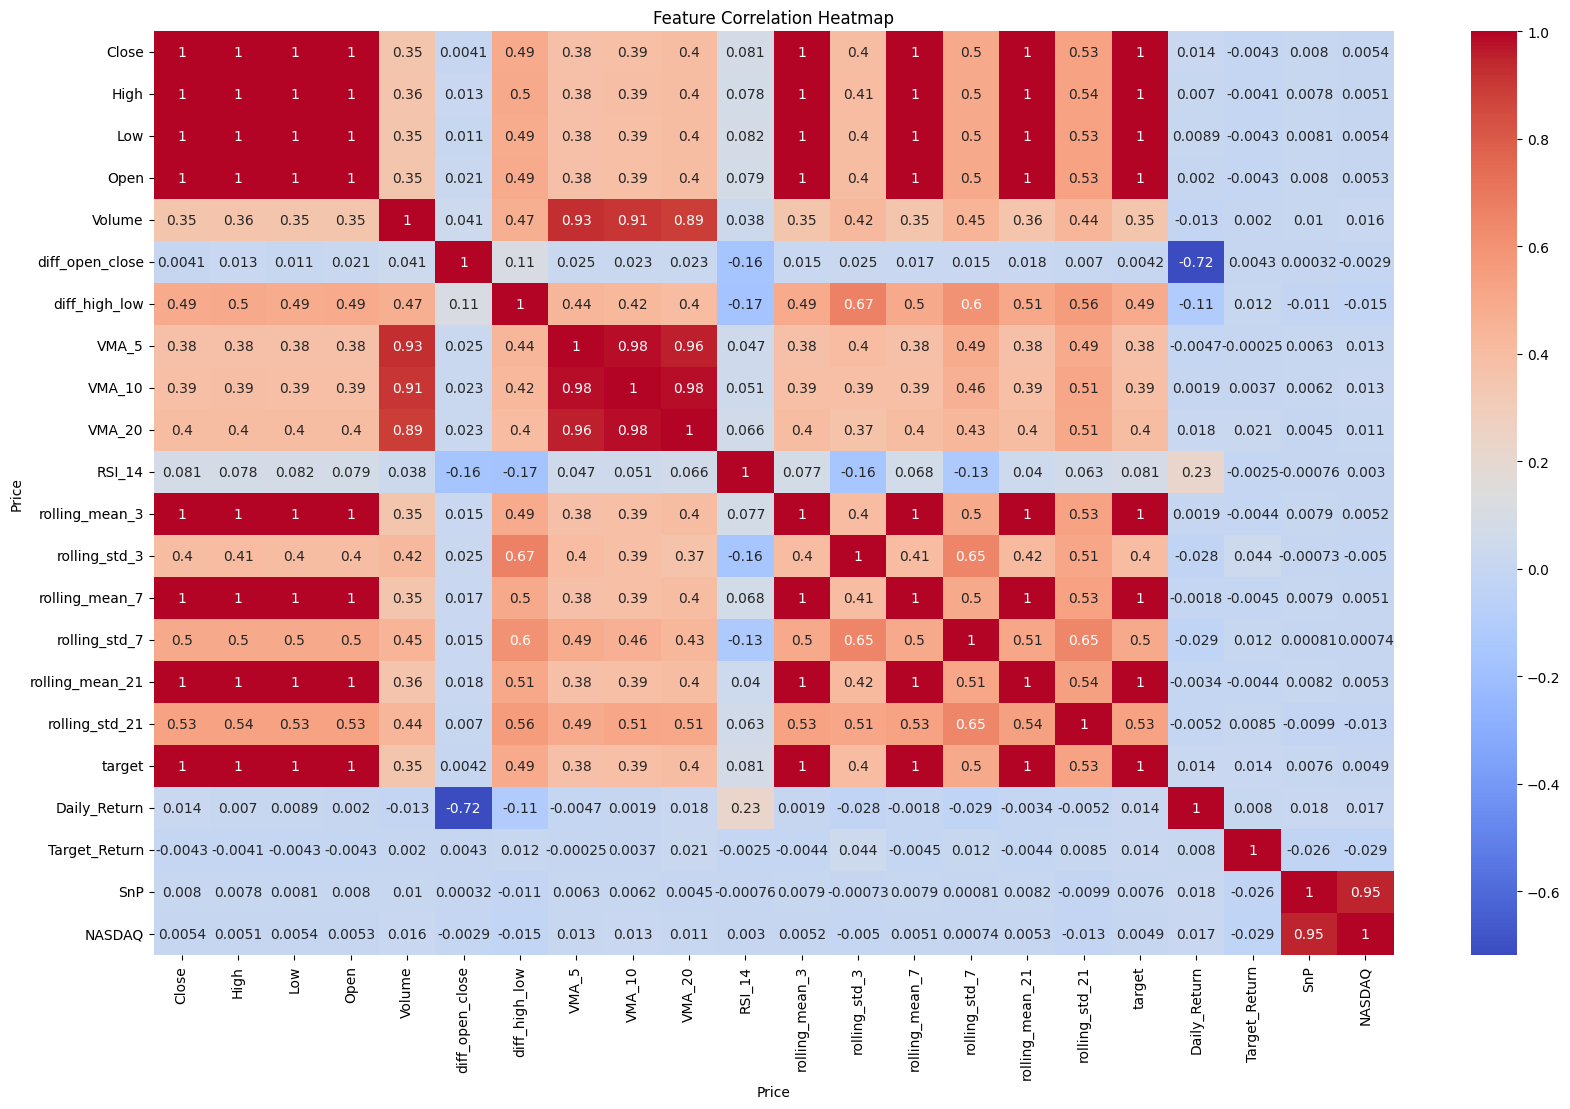

In [61]:
numeric_data = df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(20,12))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


**Feature Scaling**

In [62]:
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [63]:
# Select Features (X) and the new Target (y)
# Features (X) are the scaled columns PLUS the current day's return
X_cols = [col for col in df.columns if 'Feature' in col or col in ['Close', 'Daily_Return']]
X_raw = df[X_cols]
y_raw = df['Target_Return'].values.reshape(-1, 1)

In [64]:
# --- 2. SCALING X AND Y SEPARATELY ---
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Scale Features
scaled_X_values = feature_scaler.fit_transform(X_raw)

# Scale Target (Return)
scaled_y_values = target_scaler.fit_transform(y_raw)


# Model Training

In [65]:
# --- 3. SEQUENCE CREATION FOR LSTM ---
TIME_STEPS = 60
N_FEATURES = scaled_X_values.shape[1] # Number of input features
print(N_FEATURES)

def create_sequences(data, target, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :])
        y.append(target[i + time_steps])
    return np.array(X), np.array(y)

X_sequences, y_targets = create_sequences(scaled_X_values, scaled_y_values.flatten(), TIME_STEPS)

2


In [66]:
# 4. TRAIN-TEST SPLIT
test_size_index = int(len(X_sequences) * 0.8)
X_train_3d = X_sequences[:test_size_index]
X_test_3d = X_sequences[test_size_index:]
y_train = y_targets[:test_size_index]
y_test = y_targets[test_size_index:]
y_test_reshaped = y_test.reshape(-1, 1)



In [67]:
# --- 5. LSTM MODEL DEFINITION ---
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(TIME_STEPS, N_FEATURES)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1) # Output is the scaled return
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Training LSTM Model (Predicting Returns) ---


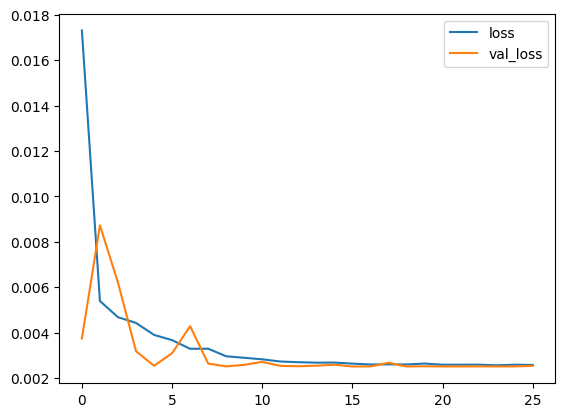

In [68]:
# 6. TRAIN AND EVALUATE
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n--- Training LSTM Model (Predicting Returns) ---")
history = lstm_model.fit(
    X_train_3d, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
plt.show()



# Save Model

In [69]:

# Save the scaler to a file so we can use the same transformation locally
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

# --- Step 6: Save model and artifacts ---
lstm_model.save("stock_lstm_model.h5")
print("✅ Model and scaler saved successfully")

# --- Step 7: Download both files ---
from google.colab import files
files.download("stock_lstm_model.h5")
files.download("feature_scaler.pkl")
files.download("target_scaler.pkl")

✅ Model and scaler saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Evaluation**

In [70]:
from sklearn.metrics import mean_squared_error, accuracy_score
# Evaluation
scaled_test_loss = lstm_model.evaluate(X_test_3d, y_test, verbose=0)
scaled_predictions = lstm_model.predict(X_test_3d, verbose=0)

# Inverse transform to get error in actual percentage units
actual_predictions = target_scaler.inverse_transform(scaled_predictions)
actual_y_test = target_scaler.inverse_transform(y_test_reshaped)

# Calculate the Actual (Unscaled) RMSE in percentage points
actual_mse = mean_squared_error(actual_y_test, actual_predictions)
actual_rmse = np.sqrt(actual_mse)

# --- CALCULATE DIRECTIONAL ACCURACY ---
# 1. Convert actual and predicted returns to binary direction (1 for up, 0 for down/flat)
actual_direction = np.where(actual_y_test > 0.005, 1, 0)
predicted_direction = np.where(actual_predictions > 0.005, 1, 0)

# 2. Calculate the Directional Accuracy
directional_accuracy = accuracy_score(actual_direction, predicted_direction)

print(f"\n--- Final LSTM Model Evaluation (TIME_STEPS={TIME_STEPS}) ---")
print(f"Scaled Test Loss (MSE): {scaled_test_loss:.6f}")
print(f"Actual (Unscaled) Test Loss (RMSE): {actual_rmse * 100:.4f} percentage points")
print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%")
print("\n--- Final Interpretation ---")
print(f"The model's optimal average error is approximately {actual_rmse * 100:.4f}% for the next day's return.")
print(f"The model successfully predicts market direction (Up or Down) {directional_accuracy * 100:.2f}% of the time on the test set.")


--- Final LSTM Model Evaluation (TIME_STEPS=60) ---
Scaled Test Loss (MSE): 0.001255
Actual (Unscaled) Test Loss (RMSE): 0.7702 percentage points
Directional Accuracy: 75.60%

--- Final Interpretation ---
The model's optimal average error is approximately 0.7702% for the next day's return.
The model successfully predicts market direction (Up or Down) 75.60% of the time on the test set.


In [71]:
# 4. Final Threshold
THRESHOLD = 0.0003

last_60_days_raw = X_raw.tail(TIME_STEPS)

# Final Prediction

In [72]:
def predict_tomorrow(last_60_days_raw, feature_scaler, target_scaler, model, threshold):
    """
    Prepares the last sequence of data, scales it, predicts the next day's return,
    and determines the trading action based on the threshold.
    """
    # 1. Reshape the last sequence into the required 3D format (1 sample, 60 time steps, 18 features)
    # The input to the scaler must be 2D (time_steps * features), not 3D
    last_sequence_2d = last_60_days_raw.values.reshape(-1, N_FEATURES)

    # 2. Scale the input features using the trained feature_scaler
    scaled_input_2d = feature_scaler.transform(last_sequence_2d)

    # 3. Reshape scaled data back to 3D for the LSTM model (1, 60, N_FEATURES)
    scaled_input_3d = scaled_input_2d.reshape(1, TIME_STEPS, N_FEATURES)

    # 4. Generate the scaled prediction
    scaled_prediction = model.predict(scaled_input_3d, verbose=0)

    # 5. Inverse transform the prediction to get the actual percentage return
    predicted_return_2d = target_scaler.inverse_transform(scaled_prediction)
    predicted_return = predicted_return_2d[0][0] # Extract the single float value

    # 6. Determine the trading action based on the threshold
    if predicted_return > threshold:
        action = "STRONG BUY"
        confidence = f"{predicted_return * 100:.4f}% UP"
    elif predicted_return < -threshold:
        action = "STRONG SELL"
        confidence = f"{-predicted_return * 100:.4f}% DOWN"
    else:
        action = "HOLD / WEAK SIGNAL"
        confidence = f"{predicted_return * 100:.4f}% (Magnitude too small)"

    return predicted_return, action, confidence

# --- EXECUTE PREDICTION ---
predicted_return, action, confidence = predict_tomorrow(
    last_60_days_raw,
    feature_scaler,
    target_scaler,
    lstm_model,
    THRESHOLD
)

print("\n--- Tomorrow's Prediction Report ---")
print(f"Based on the last {TIME_STEPS} days of data:")
print(f"Predicted Next Day Return: {predicted_return * 100:.4f}%")
print(f"Trading Action (Threshold={THRESHOLD*100:.2f}%): {action}")
print(f"Predicted Direction/Magnitude: {confidence}")
print("\nRecommendation: A trading action is executed only if the predicted return exceeds the threshold.")



--- Tomorrow's Prediction Report ---
Based on the last 60 days of data:
Predicted Next Day Return: 0.0188%
Trading Action (Threshold=0.03%): HOLD / WEAK SIGNAL
Predicted Direction/Magnitude: 0.0188% (Magnitude too small)

Recommendation: A trading action is executed only if the predicted return exceeds the threshold.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
